In [1]:
import os
from pprint import pprint
from dotenv import load_dotenv

load_dotenv()

os.environ['GOOGLE_API_KEY'] = os.getenv('GOOGLE_API_KEY')
os.environ['HF_TOKEN'] = os.getenv('HUGGINGFACE_API_KEY')
os.environ['TAVILY_API_KEY'] = os.getenv('TAVILY_API_KEY')

In [20]:
from IPython.display import display
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated, Sequence
import operator

from langchain_community.document_loaders import TextLoader, DirectoryLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import Chroma

from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough

from langchain_core.messages import BaseMessage
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import PydanticOutputParser

from tavily import TavilyClient

In [3]:
from langchain_huggingface import HuggingFaceEmbeddings
embedding = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

from langchain_google_genai import ChatGoogleGenerativeAI
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 4617.85it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [12]:
from langgraph.graph import StateGraph,MessagesState, START, END
from langgraph.graph.message import add_messages
from typing import Annotated, Literal, TypedDict
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage
from langgraph.checkpoint.memory import MemorySaver
from langgraph.prebuilt import ToolNode
from langchain.messages import AnyMessage

In [5]:
def call_model(state: MessagesState):
    messages = state['messages']
    response = llm.invoke(messages)
    return {"messages": [response]}

In [8]:
workflow=StateGraph(MessagesState)
workflow.add_node("chatbot",call_model)
workflow.add_edge(START, "chatbot")
workflow.add_edge("chatbot",END)
app1=workflow.compile()

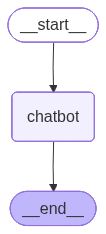

In [9]:
display(app1)

In [13]:
class MessagesState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

In [14]:
input1={"messages":["hi, my name is sunny"]}
app1.invoke(input1)

{'messages': [HumanMessage(content='hi, my name is sunny', additional_kwargs={}, response_metadata={}, id='03d2ea09-724e-4035-a204-d02afca78c01'),
  AIMessage(content="Hi Sunny! It's nice to meet you.\n\nI'm an AI assistant. How can I help you today?", additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019d33c0-209b-7702-8207-3e17c2048378-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 7, 'output_tokens': 396, 'total_tokens': 403, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 370}})]}

In [26]:
tavily_client = TavilyClient()
response = tavily_client.search("What about Iran and US war?")

In [41]:
print(response['results'][0])

{'url': 'https://www.foreignaffairs.com/united-states/how-americas-war-iran-backfired', 'title': "How America's War on Iran Backfired - Foreign Affairs", 'content': '[Skip to content](https://www.foreignaffairs.com/united-states/how-americas-war-iran-backfired#content). *   [Log In](https://www.foreignaffairs.com/user/login?destination=/united-states/how-americas-war-iran-backfired). *   [Log In](https://www.foreignaffairs.com/user/login?destination=/united-states/how-americas-war-iran-backfired). *   [Log In](https://www.foreignaffairs.com/user/login?destination=/united-states/how-americas-war-iran-backfired). *   [Log In](https://www.foreignaffairs.com/user/login?destination=/united-states/how-americas-war-iran-backfired). *   [Log In](https://www.foreignaffairs.com/user/login?destination=/united-states/how-americas-war-iran-backfired). Listen [Subscribe](https://www.foreignaffairs.com/subscribe) to unlock this feature or [Sign in](https://www.foreignaffairs.com/user/login?destinatio

In [42]:
@tool
def tavily_search(query: str):
    """this is a search tool that uses tavily to search the web. The input is a string query and the output is a string result. Make sure to use this tool when the question is about current events or when the information is not available in the training data of the model. Do not use this tool for questions that can be answered with the knowledge in the training data of the model."""
    response = tavily_client.search(query)
    return response['results'][0]['text']

In [45]:
result = tavily_client.search("What about Iran and US war?")
first_result = result["results"][0] if result.get("results") else {}
res1 = first_result.get("text") or first_result.get("content") or first_result.get("raw_content") or ""

In [48]:
first_result

{'url': 'https://www.foreignaffairs.com/united-states/how-americas-war-iran-backfired',
 'title': "How America's War on Iran Backfired - Foreign Affairs",
 'content': '[Skip to content](https://www.foreignaffairs.com/united-states/how-americas-war-iran-backfired#content). *   [Log In](https://www.foreignaffairs.com/user/login?destination=/united-states/how-americas-war-iran-backfired). *   [Log In](https://www.foreignaffairs.com/user/login?destination=/united-states/how-americas-war-iran-backfired). *   [Log In](https://www.foreignaffairs.com/user/login?destination=/united-states/how-americas-war-iran-backfired). *   [Log In](https://www.foreignaffairs.com/user/login?destination=/united-states/how-americas-war-iran-backfired). *   [Log In](https://www.foreignaffairs.com/user/login?destination=/united-states/how-americas-war-iran-backfired). Listen [Subscribe](https://www.foreignaffairs.com/subscribe) to unlock this feature or [Sign in](https://www.foreignaffairs.com/user/login?destinat

In [53]:
import requests

city = "Delhi"
# Adding ?format=3 gives a simple one-liner
response = requests.get(f"https://wttr.in/{city}?format=3")
print(response) 
# Output: Paris: 🌦️ +12°C

<Response [200]>


In [55]:
print(response.text)

delhi: âï¸   +31Â°C



In [57]:
@tool 
def weather_api_search(city: str):
    """this is a weather search tool that uses wttr.in to get the current weather of a city. The input is a string city name and the output is a string weather information. Make sure to use this tool when the question is about current weather of a city. Do not use this tool for questions that can be answered with the knowledge in the training data of the model."""
    response = requests.get(f"https://wttr.in/{city}?format=3")
    return response.text

In [58]:
tools = [weather_api_search]

In [94]:
tool_node=ToolNode(tools)

In [61]:
llm_with_tools = llm.bind_tools(tools)

In [62]:
def call_model(state: MessagesState):
    messages = state['messages']
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}

In [63]:
response=call_model({"messages": ["hi how are you?"]})

In [64]:
response

{'messages': [AIMessage(content=[{'type': 'text', 'text': "I'm doing great, thank you! How can I help you today?", 'extras': {'signature': 'CvUBAb4+9vsuoF+++ZRuORSSa8mYi1zBc09qoe7zettfcRXW60ChUzkLFL9UUKn2x5f74MTGVkn9B+ZjLFH2jnzsLu16WdooIgtuGmtG3KIn0HM0/Tz2yCpevjoglWKfsM+cx1UDBpcPPpdDHjn9ACCjicSi7nybJ8e9vWywddP1vm/zn4asRoH78unsEEz1IIk0781kRaDXzF1u1RUy4ee9PLsHIO3mANLcvIp/iEnQyxRwduloXw1o2g/FMtx1voB2FntNyY54+DhiSx59eWCcPxEbrC0We8l0xeAt/Ml8JTxDxKPUQ7v9hYw+tfWSLCb0BNijpTM='}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019d33ef-8fb3-7ad0-82f7-100a252368cf-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 116, 'output_tokens': 59, 'total_tokens': 175, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 43}})]}

In [66]:
messages = response['messages']

In [73]:
messages.tool_calls

AttributeError: 'list' object has no attribute 'tool_calls'

In [84]:
response=call_model({"messages": ["what is a weather in Delhi?"]})

In [85]:
messages = response['messages']

In [90]:
messages

[AIMessage(content='', additional_kwargs={'function_call': {'name': 'weather_api_search', 'arguments': '{"city": "Delhi"}'}, '__gemini_function_call_thought_signatures__': {'019e4406-b90f-46f4-b22a-9a5bbfd171a8': 'CoYCAb4+9vsrXgELbLD4WFLRUi9en/gXVF6WqQcvb+3kv//r41Ck3jO9NjeY0XvokeRkZTlsrYgfrOPJ4O3XkRH5TeHULKpPI8EpUIkIXr41YDY95DI5gx5pTRtQVvlsssa9Styf2r1a5jRbsaz8Y/k9q87csm52VSJCEzEfV05f1EbT6cGlWNv2PGF8dKq2jGXCB3xCu6SnPoZrig3Bt1dNrJ/XA+P+v0GmplXtsNJfRvEh0EJLDRQEZeSoFt30yoc2Ou/CmJVDB2YbYTg+QyXHIVzInuJcQVN4lb0LpCVoydYTH9PTB/RsAwe1tteffkzfiJhceKL5Deu6GlEf2rEryposSCGHOQ=='}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019d33f3-4ba0-7331-bb80-b88941acb8d8-0', tool_calls=[{'name': 'weather_api_search', 'args': {'city': 'Delhi'}, 'id': '019e4406-b90f-46f4-b22a-9a5bbfd171a8', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 118, 'output_tokens': 68, 'total_tokens': 1

In [92]:
messages[-1].tool_calls

[{'name': 'weather_api_search',
  'args': {'city': 'Delhi'},
  'id': '019e4406-b90f-46f4-b22a-9a5bbfd171a8',
  'type': 'tool_call'}]

In [93]:
def router_function(state: MessagesState) -> Literal["tools", END]:
    #print(f"here is a state from should continue {state}")
    messages = state['messages']
    last_message = messages[-1]
    #print(f"here is a last message from should continue {last_message}")
    if last_message.tool_calls:
        return "tools"
    return END

In [95]:
workflow = StateGraph(MessagesState)

workflow.add_node("agent", call_model)
workflow.add_node("tools", tool_node)

workflow.add_edge(START, "agent")

workflow.add_conditional_edges("agent",router_function,{"tools": "tools", END: END})

app2 = workflow.compile()

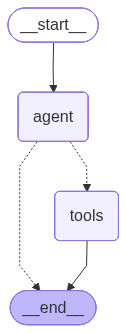

In [96]:
display(app2)

In [97]:
app2.invoke({"messages": ["hi how are you?"]})

{'messages': [HumanMessage(content='hi how are you?', additional_kwargs={}, response_metadata={}, id='227b9b49-a6ff-45f3-8dd3-cf698781989e'),
  AIMessage(content=[{'type': 'text', 'text': "Hello! I'm a large language model, I'm doing well. How can I help you today?", 'extras': {'signature': 'Cp4CAb4+9vsz/v+VzZpmHEpHX8Ytwpzo367PEwnDjGnt3xUUYnFi+1/lzL8A0s8R1smVTO47t/9Ngssm0KpcmQq+7rYjTjbCUfoF1tFR2ckPliInpI3nxkZFQk0I2axBWqPUOz/iZgg+iXYbkzMc9D8TIRA3vySc0mEjYRFB/OWEUMCfdTKcCfjmIK2UDcyVRlejiV+vOsp0QqOLluFaQFIAWIuuhUJvXJp6KOqaA2DOaqKJjHGRLMT4P0iBn46FI+Y2mGCk11KSTgwq6iPZU2DcWeaRg6htA1jAgcHauPGi1QfgqKnSXmu5hFulNFkoFbXiaFWfgJE9o+P7fmd4aFjoM304sqw6gwCFkx2otxiIi9vWAaDbqoXu8kvEf8ldeA=='}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019d33f9-9d0b-7643-9632-8a00a177fed2-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 116, 'output_tokens': 74, 'total_

In [98]:
app2.invoke({"messages": ["what is the weather in San Francisco?"]})

{'messages': [HumanMessage(content='what is the weather in San Francisco?', additional_kwargs={}, response_metadata={}, id='8f155a0b-c0c2-4650-9b06-582d73c140c6'),
  AIMessage(content='', additional_kwargs={'function_call': {'name': 'weather_api_search', 'arguments': '{"city": "San Francisco"}'}, '__gemini_function_call_thought_signatures__': {'deb53d04-c844-4183-ad6e-cecd3b2703e3': 'CqMCAb4+9vvaGsBqtodCgv3jaNyUzww3nmlbUc9XwNWW1X9/NjJWK3/vY5t2V8qIHFKJl19aHaLauazjCRxwL3+zNNUMFTW3ZbhAuOO9HyK/oCdFDTPkXhTQFXw4xmTxuMYy3Qzr4Oj7zxPYPisyRHPypSJ/iGC5G1JfYEdv7TrWknkGlKTlT/4NbKOs1BL0+xid8ajptG0EeS9k/DaXOgSWaDiqxKMzdXMGZTJk/XPybQ1XpSyUOzvxW5ipaYeUbp5DtKS7ARoqWFUuVv+GuoYnyx90pxLkE60sBsLa9HOZllVboXhLoISgi9aHbpFzjV+T7mpbMXrqpT/z+xhLpWjwJd0BZAq7FjVp3baAHwj9ZUe1QUj7SezX1NHQKc20SsJOaN6i'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019d33f9-eef9-7463-a11c-9d0ff2f1d835-0', tool_calls=[{'name': 'weathe

#### Looping

In [101]:
workflow.add_edge("tools","agent")
app2 = workflow.compile()

Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.


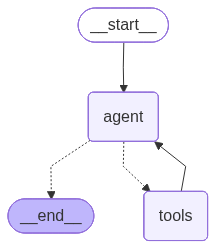

In [102]:
display(app2)

In [103]:
for output in app2.stream({"messages": ["what is the weather in San Francisco?"]}):
    for key,value in output.items():
        print(f"here is output from {key}")
        print("_______")
        print(value)
        print("\n")

here is output from agent
_______
{'messages': [AIMessage(content='', additional_kwargs={'function_call': {'name': 'weather_api_search', 'arguments': '{"city": "San Francisco"}'}, '__gemini_function_call_thought_signatures__': {'723690a7-f762-4c24-9c3f-bd366b569684': 'Cv0BAb4+9vu8t9Hkxbun4/cy5TmwwvAlHpXI0Ve9W+2fDlS07tAPizuAbE+py9Yy9bBNeB0xaw0x9/h2HVfFlmzta98Vku0nMy0RZ+ZqmMiXOxccjPoBJUTnMZ8h2HKKrAkhzlW4vep+QOvV4qYWj1upNsxM9JJ/aEF+lyiyMIsw3uDdcgIfaerL4naPF8Uc9iFHYkzgbnPt6ITTjaTUhB9yVosbfbWFavF30xfCUtDUPeUZCP9kBaXVAdxr9VGixtl5df7Hnt3TWFOBfYJ8S28cm3+xQddyQhByQxNHygBYOBopMWSDPIl4Hiuk4prS+Nl2bSGwOQpy1KhRCPZksw=='}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019d33fd-1fa7-79c0-9838-6a206e9e1a9f-0', tool_calls=[{'name': 'weather_api_search', 'args': {'city': 'San Francisco'}, 'id': '723690a7-f762-4c24-9c3f-bd366b569684', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_t

### Adding memory to the agent

In [104]:
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

In [105]:
workflow3 = StateGraph(MessagesState)

workflow3.add_node("agent", call_model)
workflow3.add_node("tools", tool_node)

workflow3.add_edge(START, "agent")

workflow3.add_conditional_edges("agent",router_function,{"tools": "tools", END: END})

workflow3.add_edge("tools", 'agent')

In [108]:
# Compile the workflow with the memory checkpointer
app3 = workflow3.compile(checkpointer=memory)

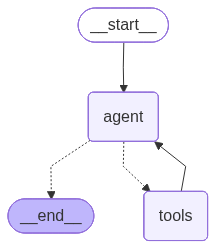

In [107]:
display(app3)

In [109]:
config = {"configurable": {"thread_id": "1"}}

In [110]:
events = app3.stream(
    {"messages": ["Hi there! My name is Boss."]}, config, stream_mode="values"
)
# stream_mode = "values" gives you the output values directly without the metadata. You can also use "events" to get the metadata along with the output values.

In [111]:
for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

Hi there! My name is Boss.
================================== Ai Message ==================================

Nice to meet you, Boss! How can I help you today?


In [112]:
events = app3.stream(
    {"messages": ["can you tell me what was my name?"]}, config, stream_mode="values"
)

In [113]:
for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

can you tell me what was my name?
================================== Ai Message ==================================

Your name is Boss.


In [114]:
events = app3.stream(
    {"messages": ["Have I asked you about the weather of Paris? Can you tell me?"]}, config, stream_mode="values"
)
for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

Have I asked you about the weather of Paris? Can you tell me?
================================== Ai Message ==================================

[{'type': 'text', 'text': "I don't have memory of past conversations, so I cannot tell you if you've asked me about the weather in Paris before. However, I can tell you what the weather is like in Paris right now.", 'extras': {'signature': 'CsADAb4+9vvZrW5CbxgGRBAqxWlFn1FSDWC16bUDXzxe2xQworP7Owd8ieJxL2UCIHq1uUW0G5wQbk5JmdwJNs+2f2ne9nKhPK8j+T3Vi7MOyBZtOfbGGTpliMPScO5VG3/t2MkVtmeZsPbtlztYv6ysrINxnxouoDjLA7JuHwtAaAIoai2fC3a2985mTkRf6H7XWsKfUPu9t6QzKLPBB/6o0y0CDHIjYflOKBufO245kSNSZrnwIiAvhxGBS7pz+0+kH3lapHuNMGuUIMPDAUpvqPYE/m+MJrTo/VbDuRNQZkXR5S0DWIvf2qTNyJaqt9uLToVPULK/oZ65vnCMHyNvD0Ez0cjI1q+4UpSYRfKG9TNXhPID2t87Yc4rpBiYvuw3nSrB3yQJ4FzE1oO0rN5XGyJpxCx0drCeF2RND2xdCJ9EkU4heUomNRAQGsWPLSFYQ8VxmElzVUS2UdDkVRmVufCmP04TLSRc6xKn+L5bdNV/ugUUKwUlW1zXyyc0KmDW9wKyTTZCxAaCBRQN8

In [115]:
memory.get(config)

{'v': 4,
 'ts': '2026-03-28T10:34:02.637600+00:00',
 'id': '1f12a91a-3781-63c5-8009-19a7f560e5f3',
 'channel_versions': {'__start__': '00000000000000000000000000000008.0.3255336623820745',
  'messages': '00000000000000000000000000000011.0.5257996577404163',
  'branch:to:agent': '00000000000000000000000000000011.0.5257996577404163',
  'branch:to:tools': '00000000000000000000000000000010.0.14170766329713302'},
 'versions_seen': {'__input__': {},
  '__start__': {'__start__': '00000000000000000000000000000007.0.163927960034431'},
  'agent': {'branch:to:agent': '00000000000000000000000000000010.0.14170766329713302'},
  'tools': {'branch:to:tools': '00000000000000000000000000000009.0.9552661926740944'}},
 'updated_channels': ['messages'],
 'channel_values': {'messages': [HumanMessage(content='Hi there! My name is Boss.', additional_kwargs={}, response_metadata={}, id='2882fa8c-8e0e-4d0c-929f-948839038c78'),
   AIMessage(content='Nice to meet you, Boss! How can I help you today?', additional_